In [14]:
import numpy as np
import pandas as pd
import statistics
from pprint import pprint
import os, glob

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Choose a run

In [15]:
markets = ['logit', 'hotelling', 'linear']
chosen = {market:None for market in markets}

for market in markets:
    avg_delta = []
    for i in range(1, 8):
        df = pd.read_csv(f"./run_{i}/{market}.csv")
        avg_delta.append(round(statistics.mean(
            [df['firm1_delta'].iloc[-1], df['firm2_delta'].iloc[-1]]
        ), 2))
    chosen[market] = int(1 + np.abs(np.array(avg_delta) - np.median(np.array(avg_delta))).argmin())

pprint(chosen)

{'hotelling': 1, 'linear': 4, 'logit': 3}


# Helper functions

In [16]:
def get_convergence_period(market_type, firm_number, tolerance=0.02):
    # 1. Construct file path and load data
    file_name = f"./run_{chosen[market_type]}/{market_type}.csv"
    if not os.path.exists(file_name):
        raise FileNotFoundError(f"The data file '{file_name}' was not found in the current directory.")
        
    df = pd.read_csv(file_name)
    
    # 2. Select the correct rolling average column
    col_name = f"firm{firm_number}_price_rolling_average"
    if col_name not in df.columns:
        raise KeyError(f"Column '{col_name}' does not exist in {file_name}.")
        
    # 3. Determine the terminal price value (the final stabilized value at the end of the run)
    terminal_price = df[col_name].iloc[-1]
    
    # 4. Check whether each period falls inside the [terminal - tolerance, terminal + tolerance] band
    lower_bound = terminal_price - tolerance
    upper_bound = terminal_price + tolerance
    is_within_band = (df[col_name] >= lower_bound) & (df[col_name] <= upper_bound)
    
    # 5. Look backwards using cumulative minimum to find where it stays inside permanently
    # reversing the series ensures that any 'False' further down the line propagates backwards
    permanently_stabilitized = is_within_band.iloc[::-1].cummin().iloc[::-1]
    
    # 6. Extract the first 't' where it becomes True and remains True till the end
    if permanently_stabilitized.any():
        converged_t = df.loc[permanently_stabilitized, 't'].iloc[0]
        return int(converged_t)
    else:
        return None

def compute_cross_run_sd(base_path, market_name, run_folders=None):
    """
    Compute cross-run SD of terminal delta for a given market.

    Parameters:
    - base_path: str, path to the directory containing the run_* folders.
    - market_name: str, e.g., 'logit', 'hotelling', 'linear'.
    - run_folders: list of folder names, default ['run_1', 'run_2', ..., 'run_7'].

    Returns:
    - dict with keys 'firm1_sd', 'firm2_sd' and the collected deltas.
    """
    if run_folders is None:
        run_folders = [f'run_{i}' for i in range(1, 8)]

    terminal_deltas_f1 = []
    terminal_deltas_f2 = []

    for folder in run_folders:
        file_path = os.path.join(base_path, folder, f'{market_name}.csv')
        try:
            df = pd.read_csv(file_path)
            # Get the last row (terminal period)
            last_row = df.iloc[-1]
            terminal_deltas_f1.append(last_row['firm1_delta'])
            terminal_deltas_f2.append(last_row['firm2_delta'])
        except FileNotFoundError:
            print(f"Warning: {file_path} not found. Skipping.")
        except KeyError as e:
            print(f"Error: Missing column in {file_path}. {e}")

    # Compute standard deviations
    sd_f1 = np.std(terminal_deltas_f1, ddof=1) if len(terminal_deltas_f1) > 1 else np.nan
    sd_f2 = np.std(terminal_deltas_f2, ddof=1) if len(terminal_deltas_f2) > 1 else np.nan

    return {
        'market': market_name,
        'firm1_sd': sd_f1,
        'firm2_sd': sd_f2,
        'all_deltas_f1': terminal_deltas_f1,
        'all_deltas_f2': terminal_deltas_f2
    }

# Logit

In [17]:
market = 'logit'

df = pd.read_csv(f"./run_{chosen[market]}/{market}.csv")
df = df.sort_values('t').reset_index(drop=True)

# Define the terminal phase (last 2000 periods) as per the PDF
terminal_start = df['t'].max() - 2000 + 1  # if t is 0..2999, then start=1000
df_terminal = df[df['t'] >= terminal_start].copy()

# Terminal price = price at the last period
terminal_price_f1 = df['firm1_price'].iloc[-1]
terminal_price_f2 = df['firm2_price'].iloc[-1]

corr = df_terminal['firm1_price'].corr(df_terminal['firm2_price'])

# Create rows for Logit market
data = {
    'Market': [market, market],
    'Firm': [1, 2],
    'Terminal price': [terminal_price_f1, terminal_price_f2],
    'Terminal phase price SD': [
        round(df_terminal['firm1_price'].std(), 2), 
        round(df_terminal['firm2_price'].std(), 2)
    ],
    'Convergence period': [get_convergence_period(market, 1), get_convergence_period(market, 2)],
    'Within-run corr(p1,p2)': [corr, corr],  # same for both firms
    'Cross-run SD of Δ': [
        round(compute_cross_run_sd('.', market)['firm1_sd'], 2), 
        round(compute_cross_run_sd('.', market)['firm2_sd'], 2)
    ]
}

pd.DataFrame(data)

,Market,Firm,Terminal price,Terminal phase price SD,Convergence period,"Within-run corr(p1,p2)",Cross-run SD of Δ
0,logit,1,1.51,0.17,8496,0.023919,5.18
1,logit,2,1.45,0.04,6596,0.023919,3.39


# Hotelling

In [18]:
market = 'hotelling'

df = pd.read_csv(f"./run_{chosen[market]}/{market}.csv")
df = df.sort_values('t').reset_index(drop=True)

# Define the terminal phase (last 2000 periods) as per the PDF
terminal_start = df['t'].max() - 2000 + 1  # if t is 0..2999, then start=1000
df_terminal = df[df['t'] >= terminal_start].copy()

# Terminal price = price at the last period
terminal_price_f1 = df['firm1_price'].iloc[-1]
terminal_price_f2 = df['firm2_price'].iloc[-1]

corr = df_terminal['firm1_price'].corr(df_terminal['firm2_price'])

# Create rows for Logit market
data = {
    'Market': [market, market],
    'Firm': [1, 2],
    'Terminal price': [terminal_price_f1, terminal_price_f2],
    'Terminal phase price SD': [
        round(df_terminal['firm1_price'].std(), 2), 
        round(df_terminal['firm2_price'].std(), 2)
    ],
    'Convergence period': [get_convergence_period(market, 1), get_convergence_period(market, 2)],
    'Within-run corr(p1,p2)': [corr, corr],  # same for both firms
    'Cross-run SD of Δ': [
        round(compute_cross_run_sd('.', market)['firm1_sd'], 2), 
        round(compute_cross_run_sd('.', market)['firm2_sd'], 2)
    ]
}

pd.DataFrame(data)

,Market,Firm,Terminal price,Terminal phase price SD,Convergence period,"Within-run corr(p1,p2)",Cross-run SD of Δ
0,hotelling,1,1.11,0.10,6,-0.011076,2.19
1,hotelling,2,1.27,0.02,2551,-0.011076,2.23


# Linear

In [19]:
market = 'linear'

df = pd.read_csv(f"./run_{chosen[market]}/{market}.csv")
df = df.sort_values('t').reset_index(drop=True)

# Define the terminal phase (last 2000 periods) as per the PDF
terminal_start = df['t'].max() - 2000 + 1  # if t is 0..2999, then start=1000
df_terminal = df[df['t'] >= terminal_start].copy()

# Terminal price = price at the last period
terminal_price_f1 = df['firm1_price'].iloc[-1]
terminal_price_f2 = df['firm2_price'].iloc[-1]

corr = df_terminal['firm1_price'].corr(df_terminal['firm2_price'])

# Create rows for Logit market
data = {
    'Market': [market, market],
    'Firm': [1, 2],
    'Terminal price': [terminal_price_f1, terminal_price_f2],
    'Terminal phase price SD': [
        round(df_terminal['firm1_price'].std(), 2), 
        round(df_terminal['firm2_price'].std(), 2)
    ],
    'Convergence period': [get_convergence_period(market, 1), get_convergence_period(market, 2)],
    'Within-run corr(p1,p2)': [corr, corr],  # same for both firms
    'Cross-run SD of Δ': [
        round(compute_cross_run_sd('.', market)['firm1_sd'], 2), 
        round(compute_cross_run_sd('.', market)['firm2_sd'], 2)
    ]
}

pd.DataFrame(data)

,Market,Firm,Terminal price,Terminal phase price SD,Convergence period,"Within-run corr(p1,p2)",Cross-run SD of Δ
0,linear,1,0.47,0.03,0,0.013512,7.14
1,linear,2,0.51,0.01,5309,0.013512,7.65


# FIGURE 6 — Full price trajectories (DDQN vs DDPG, Shock C)

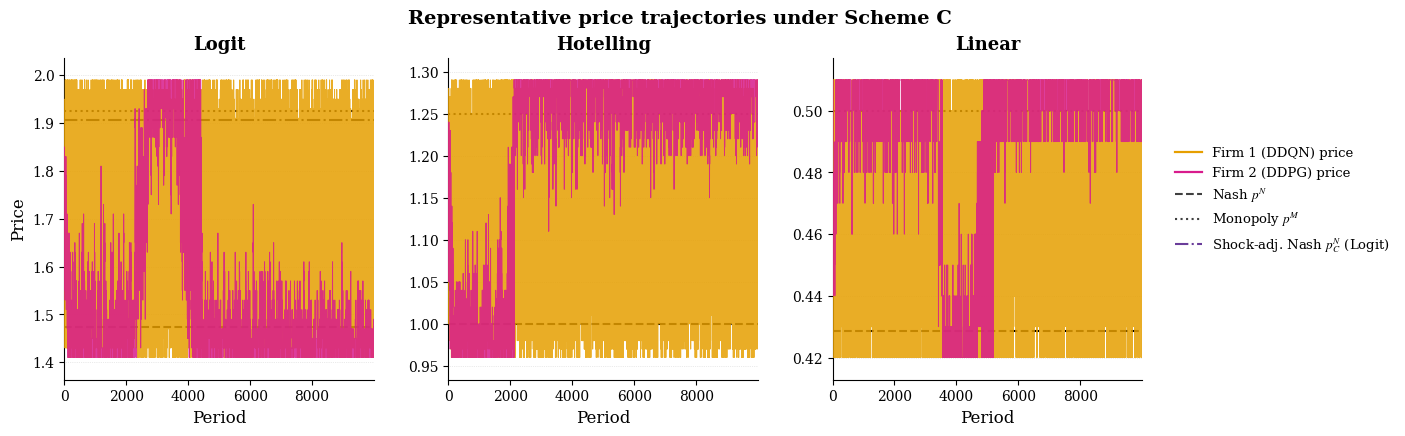

In [23]:
TRAJ_CSV = {
    "Logit":     f"./run_{chosen['logit']}/logit.csv",
    "Hotelling": f"./run_{chosen['hotelling']}/hotelling.csv",
    "Linear":    f"./run_{chosen['linear']}/linear.csv",
}
PRICE_COL_1, PRICE_COL_2 = "firm1_price", "firm2_price"   # <-- rename if your headers differ

# ----------------------------------------------------------------------
# >>> INPUT 2: benchmarks per market <
# Nash (pN), Monopoly (pM); Logit also gets shock-adjusted Nash (pN_C).
# Edit to your final Table 3 values.
# ----------------------------------------------------------------------
BENCH = {
    "Logit":     {"pN":1.473, "pM":1.925, "pN_C":1.906},
    "Hotelling": {"pN":1.000, "pM":1.250},
    "Linear":    {"pN":0.4286,"pM":0.500},
}

# ---- style (consistent with Figures 2-7) ----
plt.rcParams.update({
    "font.family":"serif",
    "font.serif":["Times New Roman","Times","DejaVu Serif"],
    "mathtext.fontset":"stix",
    "font.size":11,
    "axes.titlesize":13,
    "axes.labelsize":12,
    "xtick.labelsize":10,
    "ytick.labelsize":10,
    "axes.linewidth":0.8,
})
C1, C2 = "#E69F00", "#D81B8C"     # Firm 1 (DDQN), Firm 2 (DDPG)
MARKETS = ["Logit","Hotelling","Linear"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
fig.subplots_adjust(left=0.06, right=0.83, bottom=0.16, top=0.86, wspace=0.24)

for ax, market in zip(axes, MARKETS):
    df = pd.read_csv(TRAJ_CSV[market])
    t  = np.arange(len(df))
    ax.plot(t, df[PRICE_COL_1], color=C1, lw=0.7, alpha=0.85, zorder=3)
    ax.plot(t, df[PRICE_COL_2], color=C2, lw=0.7, alpha=0.85, zorder=3)
    b = BENCH[market]
    ax.axhline(b["pN"], ls="--", color="0", lw=1.5, zorder=2)
    ax.axhline(b["pM"], ls=":",  color="0", lw=1.5, zorder=2)
    if market == "Logit" and "pN_C" in b:
        ax.axhline(b["pN_C"], ls="-.", color="0", lw=1.5, zorder=2)
    ax.set_title(market, fontweight="bold")
    ax.set_xlabel("Period")
    ax.grid(True, axis="y", ls=":", lw=0.5, alpha=0.5, zorder=0)
    ax.spines[["top","right"]].set_visible(False)
    ax.margins(x=0.0, y=0.08)
axes[0].set_ylabel("Price")

# ---- legend ----
handles = [
    Line2D([],[],color=C1,lw=1.6,label="Firm 1 (DDQN) price"),
    Line2D([],[],color=C2,lw=1.6,label="Firm 2 (DDPG) price"),
    Line2D([],[],color="0.25",ls="--",label=r"Nash $p^{N}$"),
    Line2D([],[],color="0.25",ls=":", label=r"Monopoly $p^{M}$"),
    Line2D([],[],color="#6a3d9a",ls="-.",label=r"Shock-adj. Nash $p^{N}_{C}$ (Logit)"),
]
fig.legend(handles=handles, loc="center left", bbox_to_anchor=(0.845,0.55),
           frameon=False, fontsize=9.5)
fig.suptitle("Representative price trajectories under Scheme C",
             y=0.965, fontsize=14, fontweight="bold")

fig.savefig("figure6_trajectories.png", dpi=300, bbox_inches="tight")
fig.savefig("figure6_trajectories.pdf", bbox_inches="tight")
plt.show()

# FIGURE 7 — Rolling price & profit, final 2,000 periods (w = 500)

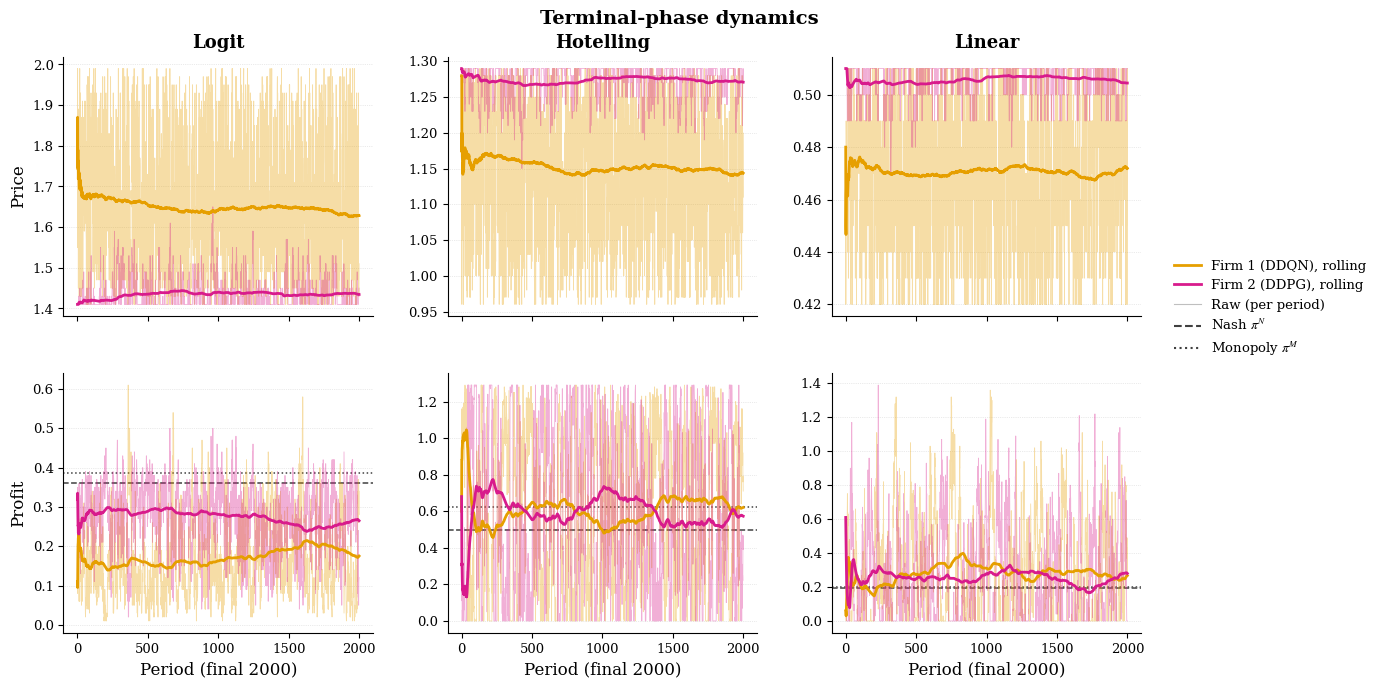

In [25]:
RUN_CSV = {
    "Logit":     f"./run_{chosen['logit']}/logit.csv",
    "Hotelling": f"./run_{chosen['hotelling']}/hotelling.csv",
    "Linear":    f"./run_{chosen['linear']}/linear.csv",
}
PCOL = {"p1":"firm1_price", "p2":"firm2_price",
        "pi1":"firm1_profit", "pi2":"firm2_profit"}

WINDOW    = 500     # rolling window (periods)
TAIL      = 2000    # final periods to display

# ----------------------------------------------------------------------
# >>> INPUT 2: Nash / Monopoly PROFIT benchmarks per market <
# (per-firm). Edit to your final values.
# ----------------------------------------------------------------------
PROFIT_BENCH = {
    "Logit":     {"piN":0.3596, "piM":0.3855},   # <-- replace
    "Hotelling": {"piN":0.500, "piM":0.625},   # <-- replace
    "Linear":    {"piN":0.1959, "piM":0.200},   # <-- replace (see Linear monopoly note)
}

# ---- style ----
plt.rcParams.update({
    "font.family":"serif","font.serif":["Times New Roman","Times","DejaVu Serif"],
    "mathtext.fontset":"stix","font.size":11,"axes.titlesize":13,"axes.labelsize":12,
    "xtick.labelsize":9.5,"ytick.labelsize":9.5,"axes.linewidth":0.8,
})
C1, C2 = "#E69F00", "#D81B8C"
MARKETS = ["Logit","Hotelling","Linear"]

def roll(series): return pd.Series(series).rolling(WINDOW, min_periods=1).mean().values

fig, axes = plt.subplots(2, 3, figsize=(14, 7.2), sharex="col")
fig.subplots_adjust(left=0.06, right=0.83, bottom=0.10, top=0.90, wspace=0.24, hspace=0.22)

for j, market in enumerate(MARKETS):
    df = pd.read_csv(RUN_CSV[market]).tail(TAIL).reset_index(drop=True)
    t  = np.arange(len(df))

    # --- top row: PRICE ---
    axp = axes[0, j]
    for col, c in [(PCOL["p1"], C1), (PCOL["p2"], C2)]:
        axp.plot(t, df[col],       color=c, lw=0.6, alpha=0.35, zorder=2)   # raw
        axp.plot(t, roll(df[col]), color=c, lw=2.0, zorder=3)               # rolling
    axp.set_title(market, fontweight="bold")
    if j == 0: axp.set_ylabel("Price")
    axp.grid(True, axis="y", ls=":", lw=0.5, alpha=0.5, zorder=0)
    axp.spines[["top","right"]].set_visible(False)

    # --- bottom row: PROFIT ---
    axq = axes[1, j]
    for col, c in [(PCOL["pi1"], C1), (PCOL["pi2"], C2)]:
        axq.plot(t, df[col],       color=c, lw=0.6, alpha=0.35, zorder=2)
        axq.plot(t, roll(df[col]), color=c, lw=2.0, zorder=3)
    pb = PROFIT_BENCH[market]
    axq.axhline(pb["piN"], ls="--", color="0.25", lw=1.1, zorder=1)
    axq.axhline(pb["piM"], ls=":",  color="0.25", lw=1.1, zorder=1)
    axq.set_xlabel(f"Period (final {TAIL})")
    if j == 0: axq.set_ylabel("Profit")
    axq.grid(True, axis="y", ls=":", lw=0.5, alpha=0.5, zorder=0)
    axq.spines[["top","right"]].set_visible(False)

# ---- legend ----
handles = [
    Line2D([],[],color=C1,lw=2.0,label="Firm 1 (DDQN), rolling"),
    Line2D([],[],color=C2,lw=2.0,label="Firm 2 (DDPG), rolling"),
    Line2D([],[],color="0.5",lw=0.8,alpha=0.5,label="Raw (per period)"),
    Line2D([],[],color="0.25",ls="--",label=r"Nash $\pi^{N}$"),
    Line2D([],[],color="0.25",ls=":", label=r"Monopoly $\pi^{M}$"),
]
fig.legend(handles=handles, loc="center left", bbox_to_anchor=(0.845,0.55),
           frameon=False, fontsize=9.5)
fig.suptitle(f"Terminal-phase dynamics",
             y=0.965, fontsize=14, fontweight="bold")

# fig.suptitle(f"Terminal-phase dynamics (final {TAIL} periods, {WINDOW}-period rolling mean)", y=0.965, fontsize=14, fontweight="bold")

fig.savefig("figure7_rolling.png", dpi=300, bbox_inches="tight")
fig.savefig("figure7_rolling.pdf", bbox_inches="tight")
plt.show()